In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
data=pd.read_csv("../Data/final_data.csv")
data.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   useridx            52930 non-null  int64
 1   continent          52930 non-null  str  
 2   region             52930 non-null  str  
 3   usercountry        52930 non-null  str  
 4   usercity           52922 non-null  str  
 5   transactionid      52930 non-null  int64
 6   visityearx         52930 non-null  int64
 7   visitmonthx        52930 non-null  int64
 8   attractionidx      52930 non-null  int64
 9   ratingx            52930 non-null  int64
 10  visitmodex         52930 non-null  str  
 11  attraction         52930 non-null  str  
 12  attractionaddress  52930 non-null  str  
 13  attractiontype     52930 non-null  str  
 14  attractioncity     52930 non-null  str  
 15  attractioncountry  52930 non-null  str  
dtypes: int64(6), str(10)
memory usage: 13.1 MB


In [4]:
data.isna().sum()

useridx              0
continent            0
region               0
usercountry          0
usercity             8
transactionid        0
visityearx           0
visitmonthx          0
attractionidx        0
ratingx              0
visitmodex           0
attraction           0
attractionaddress    0
attractiontype       0
attractioncity       0
attractioncountry    0
dtype: int64

In [5]:
data.dropna(subset=["usercity"],axis=0,inplace=True)

In [6]:
data.isna().sum()

useridx              0
continent            0
region               0
usercountry          0
usercity             0
transactionid        0
visityearx           0
visitmonthx          0
attractionidx        0
ratingx              0
visitmodex           0
attraction           0
attractionaddress    0
attractiontype       0
attractioncity       0
attractioncountry    0
dtype: int64

In [7]:
data.describe()

,useridx,transactionid,visityearx,visitmonthx,attractionidx,ratingx
count,52922.000000,52922.000000,52922.000000,52922.000000,52922.000000,52922.000000
mean,45025.888364,70418.108783,2016.351971,6.632497,759.672272,4.157609
std,25072.959559,66303.526122,1.732955,3.392764,210.730158,0.970575
min,14.000000,3.000000,2013.000000,1.000000,369.000000,1.000000
25%,23470.000000,19645.250000,2015.000000,4.000000,640.000000,4.000000
50%,45533.500000,42770.500000,2016.000000,7.000000,737.000000,4.000000
75%,66670.250000,105640.750000,2018.000000,9.000000,841.000000,5.000000
max,88190.000000,211241.000000,2022.000000,12.000000,1297.000000,5.000000


In [8]:
y=data.visitmodex
y.value_counts(),y.head()

(visitmodex
 Couples     21617
 Family      15215
 Friends     10944
 Solo         4523
 Business      623
 Name: count, dtype: int64,
 0    Friends
 1    Friends
 2    Friends
 3     Family
 4    Friends
 Name: visitmodex, dtype: str)

In [9]:
x=data.drop("visitmodex",axis=1)
x.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [10]:
x["iscovid"]=x.visityearx.apply(lambda x: 1 if x in [2020,2021] else 0)

In [11]:
category=[cols for cols in x.columns if x[cols].dtype=="str"]
numeric=[cols for cols in x.columns if x[cols].dtype!="str"]
category,numeric

(['continent',
  'region',
  'usercountry',
  'usercity',
  'attraction',
  'attractionaddress',
  'attractiontype',
  'attractioncity',
  'attractioncountry'],
 ['useridx',
  'transactionid',
  'visityearx',
  'visitmonthx',
  'attractionidx',
  'ratingx',
  'iscovid'])

<Axes: xlabel='continent', ylabel='count'>

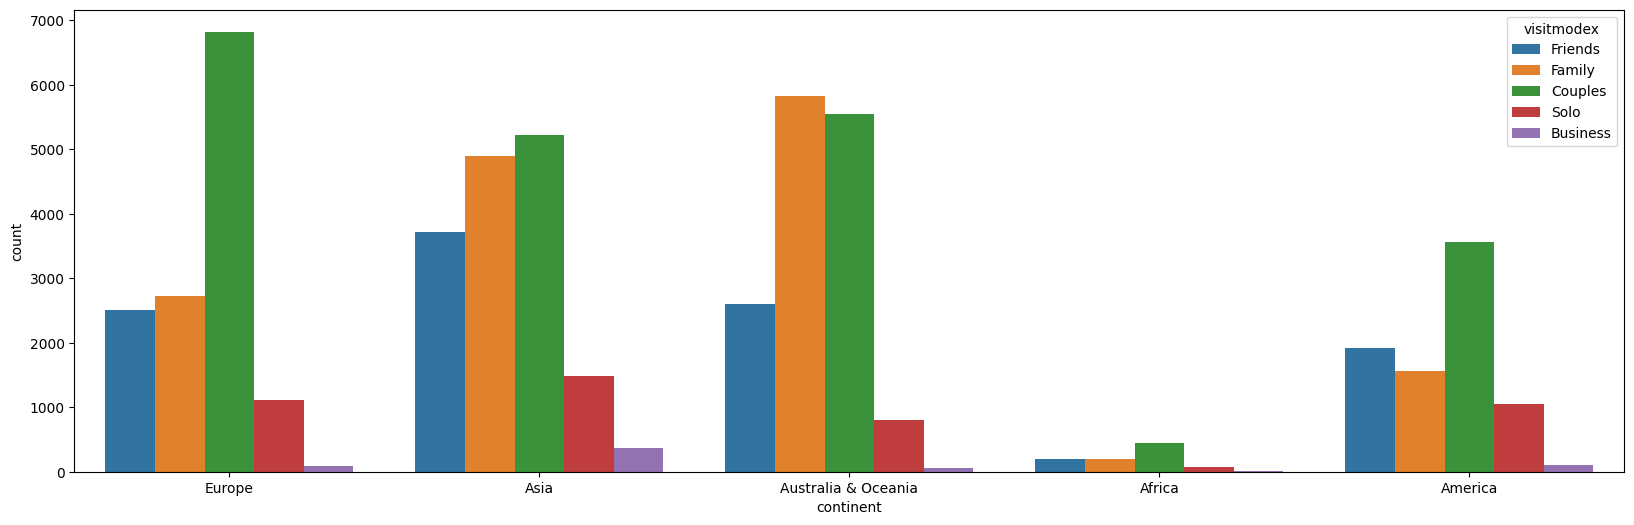

In [12]:
plt.figure(figsize=(20,6))
sns.countplot(x=data.continent,hue=y)

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
y[:5]

array([3, 3, 3, 2, 3])

In [14]:
from scipy.stats import chi2_contingency
chi2_table=pd.DataFrame(columns=["feature","null_hypothesis","correlated"])
for i in range(len(category)):
    chi_score=chi2_contingency(pd.crosstab(data[category[i]],y))[1]
    alpha=0.05
    if chi_score<alpha:
        chi2_table.loc[i]=[category[i],"Reject","Correlated"]
    else:
        chi2_table.loc[i]=[category[i],"Accept","Not correlated"]
chi2_table  

,feature,null_hypothesis,correlated
0,continent,Reject,Correlated
1,region,Reject,Correlated
2,usercountry,Reject,Correlated
3,usercity,Reject,Correlated
4,attraction,Reject,Correlated
5,attractionaddress,Reject,Correlated
6,attractiontype,Reject,Correlated
7,attractioncity,Reject,Correlated
8,attractioncountry,Reject,Correlated


In [15]:
#cramersV helps to identify the correlation strength between the the categorical and the target feature
def cramersV(x,y):
    cm=pd.crosstab(x,y)
    chi2=chi2_contingency(cm)[0]
    n=cm.sum().sum()
    r,k=cm.shape
    return np.sqrt(chi2/(n*(min(r-1,k-1))))

for i in category:
    print(i,"    |    ",cramersV(data[i],y))

continent     |     0.11286296907043131
region     |     0.1317594355688223
usercountry     |     0.15780980226381486
usercity     |     0.3888811421181505
attraction     |     0.17631826105534604
attractionaddress     |     0.17349290613756316
attractiontype     |     0.1680482653145423
attractioncity     |     0.12734760707147305
attractioncountry     |     0.15936508688053502


In [16]:
for i in category:
    print(i,data[i].nunique())

continent 5
region 22
usercountry 153
usercity 5545
attraction 30
attractionaddress 25
attractiontype 17
attractioncity 3
attractioncountry 2


In [17]:
x.head(2)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,iscovid
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,0
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon,0


<Axes: >

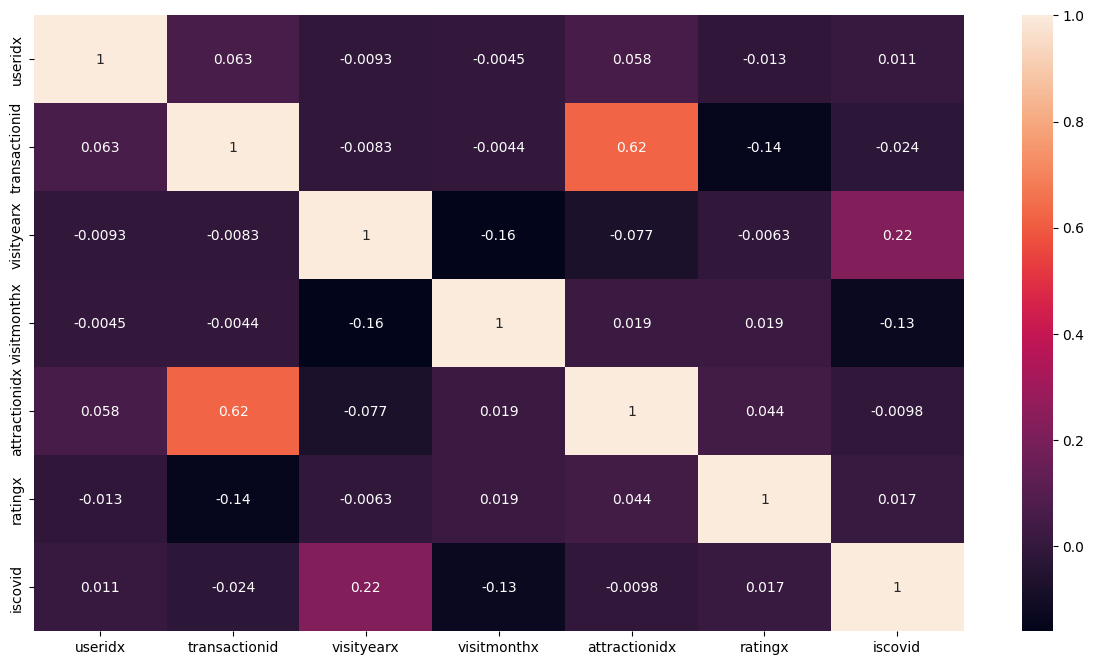

In [18]:
plt.figure(figsize=(15,8))
#It is use to find out the linear correlation beweeen numeric only if the realtion is linear it cannot carpture non-linear/complex relation
sns.heatmap(x.corr(numeric_only=True),annot=True)

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y)
x_train.shape,x_test.shape,y_train.shape,y_test.shape   

((42337, 16), (10585, 16), (42337,), (10585,))

In [20]:
a=x_train.groupby("useridx")["attractionidx"].value_counts()
a

useridx  attractionidx
14       748              2
         640              1
16       640              3
         824              1
         481              1
                         ..
88185    369              1
         737              1
88187    824              1
88189    640              1
88190    748              1
Name: count, Length: 37068, dtype: int64

In [21]:
x_train["user_attraction_mode"]=x_train.set_index(["useridx","attractionidx"]).index.map(a)
x_train.user_attraction_mode=x_train.user_attraction_mode.astype("float")
x_train.head(2)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,iscovid,user_attraction_mode
51035,84691,Asia,Middle East,Cyprus,Limassol City,34018,2016,1,673,3,Seminyak Beach,Seminyak,Beaches,Douala,Cameroon,0,1.0
906,1586,Europe,Western Europe,Netherlands,Deventer,43815,2015,5,650,4,Sanur Beach,Sanur,Beaches,Douala,Cameroon,0,1.0


In [22]:
default_user_attraction_mode=x_train.user_attraction_mode.value_counts().sort_values(ascending=False).iloc[0]
x_test["user_attraction_mode"]=x_test.set_index(["useridx","attractionidx"]).index.map(a).fillna(default_user_attraction_mode)
x_test.user_attraction_mode=x_test.user_attraction_mode.astype("float")
x_test.head(2)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,iscovid,user_attraction_mode
28997,49642,America,Northern America,United States,Greenwich,206659,2016,4,1238,4,Sewu Temple,Yogyakarta,Ancient Ruins,N'Djamena,Chad,0,33538.0
43573,72745,America,Northern America,United States,Los Angeles,7933,2017,2,640,5,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,0,33538.0


In [23]:
b=x_train.groupby("attractionidx")["transactionid"].value_counts()
b

attractionidx  transactionid
369            144831           1
               144439           1
               144930           1
               145243           1
               144167           1
                               ..
1297           210775           1
               210483           1
               211029           1
               210425           1
               210614           1
Name: count, Length: 42337, dtype: int64

In [24]:
x_train["attraction_transaction_mode"]=x_train.set_index(["attractionidx","transactionid"]).index.map(b)
x_train.head(2)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,iscovid,user_attraction_mode,attraction_transaction_mode
51035,84691,Asia,Middle East,Cyprus,Limassol City,34018,2016,1,673,3,Seminyak Beach,Seminyak,Beaches,Douala,Cameroon,0,1.0,1
906,1586,Europe,Western Europe,Netherlands,Deventer,43815,2015,5,650,4,Sanur Beach,Sanur,Beaches,Douala,Cameroon,0,1.0,1


In [25]:
default_attraction_transaction_mode=x_train.attraction_transaction_mode.value_counts().sort_values(ascending=False).iloc[0]
x_test["attraction_transaction_mode"]=x_test.set_index(["attractionidx","transactionid"]).index.map(b).fillna(default_attraction_transaction_mode)  
x_test.head(2)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,iscovid,user_attraction_mode,attraction_transaction_mode
28997,49642,America,Northern America,United States,Greenwich,206659,2016,4,1238,4,Sewu Temple,Yogyakarta,Ancient Ruins,N'Djamena,Chad,0,33538.0,42337.0
43573,72745,America,Northern America,United States,Los Angeles,7933,2017,2,640,5,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,0,33538.0,42337.0


In [26]:
numx=[cols for cols in x_train.columns if x_train[cols].dtype!="str"]
numx

['useridx',
 'transactionid',
 'visityearx',
 'visitmonthx',
 'attractionidx',
 'ratingx',
 'iscovid',
 'user_attraction_mode',
 'attraction_transaction_mode']

In [27]:
#Here we use mutual_info_classif to capture the non-linear/complex trend if it exsistd between the numeric features or not.
from sklearn.feature_selection import mutual_info_classif
for i in numx:
    mi=mutual_info_classif(x_train[[i]],y_train)
    print(i , "     |     ",mi)

useridx      |      [0.18463246]
transactionid      |      [0.12007591]
visityearx      |      [0]
visitmonthx      |      [0.01475803]
attractionidx      |      [0.05380818]
ratingx      |      [0]
iscovid      |      [0.00045688]
user_attraction_mode      |      [0.01807894]
attraction_transaction_mode      |      [0]


In [28]:
x_train=x_train.drop(["attractionaddress","attractionidx","useridx","transactionid"],axis=1)
x_test=x_test.drop(["attractionaddress","attractionidx","useridx","transactionid"],axis=1)
x_train.shape,x_test.shape

((42337, 14), (10585, 14))

In [29]:
finalcat=[cols for cols in x_train.columns if x_train[cols].dtype=="str"]
finalnum=[cols for cols in x_train.columns if x_train[cols].dtype!="str"]
finalcat,finalnum

(['continent',
  'region',
  'usercountry',
  'usercity',
  'attraction',
  'attractiontype',
  'attractioncity',
  'attractioncountry'],
 ['visityearx',
  'visitmonthx',
  'ratingx',
  'iscovid',
  'user_attraction_mode',
  'attraction_transaction_mode'])

In [30]:
for i in finalcat:
    print(i,x_train[i].nunique())

continent 5
region 22
usercountry 150
usercity 5026
attraction 30
attractiontype 17
attractioncity 3
attractioncountry 2


In [31]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from category_encoders import BinaryEncoder

In [32]:
ohe=[]
binenc=[]
for i in finalcat:
    if x_train[i].nunique()>5:
        binenc.append(i)
    else:
        ohe.append(i)
ohe,binenc

(['continent', 'attractioncity', 'attractioncountry'],
 ['region', 'usercountry', 'usercity', 'attraction', 'attractiontype'])

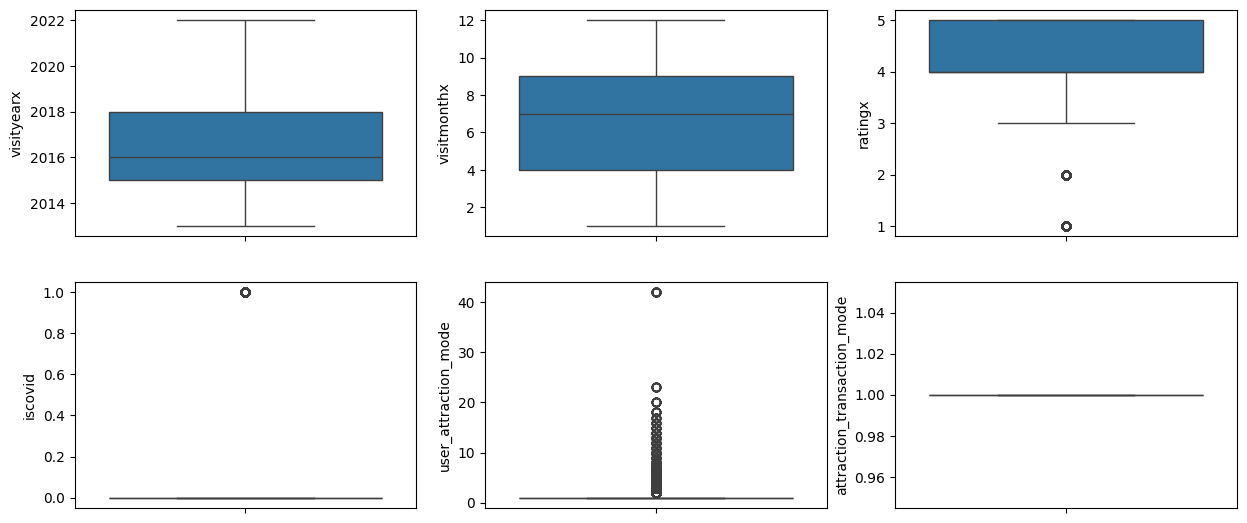

In [33]:
plt.figure(figsize=(15,10))
for i in range(len(finalnum)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x_train[finalnum[i]])

In [34]:
def cap_outliers(x_train,cols):
    q1=x_train[cols].quantile(0.25)
    q2=x_train[cols].quantile(0.5)
    q3=x_train[cols].quantile(0.75)
    iqr=q3-q1
    lowerbound=q1-1.5*iqr
    upperbound=q3+1.5*iqr
    x_train.loc[x_train[cols]<lowerbound,cols]=lowerbound
    x_train.loc[x_train[cols]>upperbound,cols]=upperbound
    return x_train

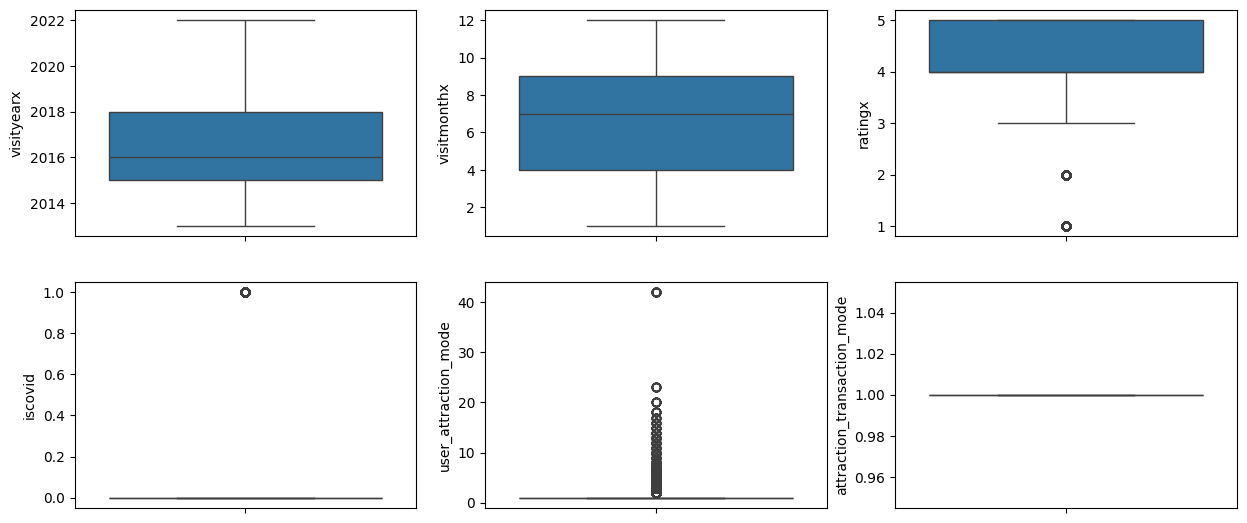

In [35]:
plt.figure(figsize=(15,10))
for i in range(len(finalnum)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x_train[finalnum[i]])

In [36]:
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(
    [
        ("OneHotEncoding",OneHotEncoder(),ohe),
        ("StandardScaler",StandardScaler(),finalnum),
        # ("Robustscaler",RobustScaler(),rscales),
        ("BinaryEncoder",BinaryEncoder(),binenc)
    ],
    remainder="drop"
)

In [37]:
x_train.shape,x_test.shape  

((42337, 14), (10585, 14))

In [38]:
x_train=ct.fit_transform(x_train)
x_test=ct.transform(x_test)

In [39]:
#Heer we will not use pca as it is not used for tree based models it is used for linear models/linear features.
# from sklearn.decomposition import PCA
# pca=PCA(n_components=0.95)
# x_train=pca.fit_transform(x_train)
# x_test=pca.transform(x_test)
# x_train.shape,x_test.shape

In [40]:
x_train[0]

array([ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
       -0.20516342, -1.65771441, -1.19599013, -0.10422982, -0.25261766,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ])

In [41]:
x_test[0]

array([ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00, -2.05163418e-01, -7.74606391e-01,
       -1.64356657e-01, -1.04229821e-01,  1.72092612e+04,  4.23360000e+04,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  0.00000000e+00,  1.00000000e+00])

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [43]:
from sklearn.metrics import classification_report,confusion_matrix

In [44]:
model=LogisticRegression(max_iter=800)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred,y_test

(array([4, 4, 1, ..., 4, 1, 1], shape=(10585,)),
 array([3, 1, 4, ..., 3, 3, 3], shape=(10585,)))

In [45]:
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(cm)

[[   0   11    9    9   95]
 [   0  575  114   89 3546]
 [   0  296  256   92 2399]
 [   0  253  122  158 1656]
 [   0  136   47   55  667]]


c:\Users\S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [46]:
print(cr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       124
           1       0.45      0.13      0.21      4324
           2       0.47      0.08      0.14      3043
           3       0.39      0.07      0.12      2189
           4       0.08      0.74      0.14       905

    accuracy                           0.16     10585
   macro avg       0.28      0.21      0.12     10585
weighted avg       0.41      0.16      0.16     10585



In [47]:
model.score(x_train,y_train),model.score(x_test,y_test) 

(0.4705104282306257, 0.15644780349551252)

In [48]:
model=RandomForestClassifier(n_estimators=20,max_depth=35,criterion="entropy",random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred,y_test

(array([2, 1, 4, ..., 1, 3, 3], shape=(10585,)),
 array([3, 1, 4, ..., 3, 3, 3], shape=(10585,)))

In [49]:
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(cm)

[[  14   40   42   23    5]
 [   5 2983  851  368  117]
 [  10 1203 1504  239   87]
 [  14  992  542  544   97]
 [   1  470  173  103  158]]


In [50]:
print(cr)

              precision    recall  f1-score   support

           0       0.32      0.11      0.17       124
           1       0.52      0.69      0.60      4324
           2       0.48      0.49      0.49      3043
           3       0.43      0.25      0.31      2189
           4       0.34      0.17      0.23       905

    accuracy                           0.49     10585
   macro avg       0.42      0.34      0.36     10585
weighted avg       0.47      0.49      0.47     10585



In [51]:
model.score(x_train,y_train),model.score(x_test,y_test)

(0.945697616741857, 0.4915446386395843)

In [52]:
model=DecisionTreeClassifier(max_depth=15,criterion="entropy")
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred,y_test

(array([2, 1, 4, ..., 1, 3, 3], shape=(10585,)),
 array([3, 1, 4, ..., 3, 3, 3], shape=(10585,)))

In [53]:
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(cm)

[[   4   34   32   30   24]
 [  78 2556  874  441  375]
 [  39 1137 1285  348  234]
 [  39  926  479  507  238]
 [  22  406  171  132  174]]


In [54]:
print(cr)

              precision    recall  f1-score   support

           0       0.02      0.03      0.03       124
           1       0.51      0.59      0.54      4324
           2       0.45      0.42      0.44      3043
           3       0.35      0.23      0.28      2189
           4       0.17      0.19      0.18       905

    accuracy                           0.43     10585
   macro avg       0.30      0.29      0.29     10585
weighted avg       0.42      0.43      0.42     10585



In [55]:
model.score(x_train,y_train),model.score(x_test,y_test)

(0.6716819803009189, 0.42758620689655175)

In [56]:
# model=SVC(kernel="poly",C=1)
# model.fit(x_train,y_train)
# y_pred=model.predict(x_test)
# y_pred,y_test

In [57]:
# cm=confusion_matrix(y_test,y_pred)
# cr=classification_report(y_test,y_pred)
# print(cm)

In [58]:
# print(cr)

In [59]:
# model.score(x_train,y_train),model.score(x_test,y_test)

In [60]:
model=XGBClassifier(n_estimators=5,max_depth=5,learning_rate=0.1,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred,y_test

(array([2, 1, 4, ..., 1, 1, 1], shape=(10585,)),
 array([3, 1, 4, ..., 3, 3, 3], shape=(10585,)))

In [61]:
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(cm)

[[   1   72   38   12    1]
 [   0 3349  885   77   13]
 [   0 1652 1299   87    5]
 [   0 1431  608  129   21]
 [   0  676  160   43   26]]


In [62]:
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       124
           1       0.47      0.77      0.58      4324
           2       0.43      0.43      0.43      3043
           3       0.37      0.06      0.10      2189
           4       0.39      0.03      0.05       905

    accuracy                           0.45     10585
   macro avg       0.53      0.26      0.24     10585
weighted avg       0.44      0.45      0.39     10585



In [63]:
model.score(x_train,y_train),model.score(x_test,y_test)

(0.47785624867137494, 0.4538497874350496)

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from xgboost import XGBRegressor
model={
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "SVR":SVR(),
    "XGBClassifier":XGBClassifier(),
    "LogisticRegression":LogisticRegression(),
}

param_grid={
    "DecisionTreeClassifier":{
        "max_depth":[8,10,12,14],
        "criterion":["gini", "entropy"]
    },
    "RandomForestClassifier":{
        "max_depth":[10,15,20,25],
        "criterion":["gini", "entropy"],
        "n_estimators":[10,15,20,25],
    },
    "SVR":{
        "kernel":["rbf","poly"],
        "epsilon":[0.1]
    },
    "XGBClassifier":{
        "n_estimators":[4,5,6,7,8],
        "max_depth":[4,5,6,7,8]
    },
    "LogisticRegression":{
         "max_iter":[300,400,500],    
    }
}

In [65]:
# 	model	score	best_params	best_estimator
# 0	DecisionTreeClassifier()	0.474289	{'max_depth': 10, 'criterion': 'entropy'}	DecisionTreeClassifier(criterion='entropy', ma...
# 1	RandomForestClassifier()	0.509105	{'n_estimators': 25, 'max_depth': 15, 'criteri...	(DecisionTreeClassifier(criterion='entropy', m...
# 2	SVR()	-0.030728	{'kernel': 'rbf', 'epsilon': 0.1}	SVR()
# 3	XGBClassifier(base_score=None, booster=None, c...	0.495429	{'n_estimators': 7, 'max_depth': 8}	XGBClassifier(base_score=None, booster=None, c...
# 4	LogisticRegression()	0.465267	{'max_iter': 300}	LogisticRegression(max_iter=300)


In [66]:
# rscv_table=pd.DataFrame(columns=["model","score","best_params","best_estimator"])
# j=0
# for i in model:
#     rscv=RandomizedSearchCV(estimator=model[i],param_distributions=param_grid[i],cv=5,return_train_score=True,verbose=3)
#     rscv.fit(x_train,y_train)
#     rscv_table.loc[j]=[model[i],rscv.best_score_,rscv.best_params_,rscv.best_estimator_]
#     j+=1
# rscv_table

In [67]:
model=RandomForestClassifier(criterion='entropy', max_depth=25, n_estimators=15,random_state=42)
model.fit(x_train,y_train)
model.score(x_train,y_train),model.score(x_test,y_test)

(0.9344544960672697, 0.49844119036372225)

In [68]:
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[  17,   40,   42,   18,    7],
       [   9, 3075,  805,  325,  110],
       [  10, 1225, 1493,  243,   72],
       [  11, 1048,  521,  520,   89],
       [   2,  474,  159,   99,  171]])

In [69]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.35      0.14      0.20       124
           1       0.52      0.71      0.60      4324
           2       0.49      0.49      0.49      3043
           3       0.43      0.24      0.31      2189
           4       0.38      0.19      0.25       905

    accuracy                           0.50     10585
   macro avg       0.44      0.35      0.37     10585
weighted avg       0.48      0.50      0.48     10585



In [70]:
model=XGBClassifier(max_depth=15, n_estimators=15,random_state=42)
model.fit(x_train,y_train)
model.score(x_train,y_train),model.score(x_test,y_test)

(0.8612324916739496, 0.48474256022673595)

In [71]:
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[   8,   53,   32,   20,   11],
       [   7, 2953,  807,  341,  216],
       [  10, 1127, 1480,  273,  153],
       [   9,  999,  515,  505,  161],
       [   4,  448,  147,  121,  185]])

In [72]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.21      0.06      0.10       124
           1       0.53      0.68      0.60      4324
           2       0.50      0.49      0.49      3043
           3       0.40      0.23      0.29      2189
           4       0.25      0.20      0.23       905

    accuracy                           0.48     10585
   macro avg       0.38      0.33      0.34     10585
weighted avg       0.47      0.48      0.47     10585



In [73]:
import joblib
# finalmodel=XGBClassifier(max_depth=7, n_estimators=7)
# joblib.dump(finalmodel,"visitmodemodel.pkl")

In [74]:
covidyear=[2020,2021]

In [75]:
# x["iscovid"]=x.visityearx.apply(lambda x: 1 if x in [2020,2021] else 0)
# x_test["user_visit_mode"]=x_test.set_index(["useridx","visitmodex"]).index.map(a).fillna(x_train.user_visit_mode.value_counts().sort_values(ascending=False).iloc[0])
# x_test.user_visit_mode=x_test.user_visit_mode.astype("float")
# x_test["attraction_visit_mode"]=x_test.set_index(["attractionidx","visitmodex"]).index.map(b).fillna(x_train.attraction_visit_mode.value_counts().sort_values(ascending=False).iloc[0])  
# ohe=[]
# binenc=[]
# for i in finalcat:
#     if x_train[i].nunique()>5:
#         binenc.append(i)
#     else:
#         ohe.append(i)
# x_test=ct.transform(x_test)

In [76]:
from sklearn.base import BaseEstimator,TransformerMixin

class visitmodeclassifyfeaturebuilder(BaseEstimator,TransformerMixin):
    def __init__(self,covidyear,a,b,default_user_attraction_mode,default_attraction_transaction_mode):
        self.covidyear=covidyear
        self.a=a
        self.b=b 
        self.default_user_attraction_mode=default_user_attraction_mode
        self.default_attraction_transaction_mode=default_attraction_transaction_mode
        
    def fit(self,x,y=None):
        return self
    
    def transform(self,x):
        x=x.copy()
        x["iscovid"]=x.visityearx.apply(lambda x: 1 if x in self.covidyear else 0)
        x["user_attraction_mode"]=x.set_index(["useridx","attractionidx"]).index.map(self.a).fillna(self.default_user_attraction_mode)
        x["attraction_transaction_mode"]=x.set_index(["attractionidx","transactionid"]).index.map(self.b).fillna(self.default_attraction_transaction_mode)
        x.user_attraction_mode=x.user_attraction_mode.astype("float")
        x.attraction_transaction_mode=x.attraction_transaction_mode.astype("float")
        x=x.drop(columns=["attractionaddress","attractionidx","useridx","transactionid"])
        return x

In [77]:
from sklearn.pipeline import Pipeline
pipeline=Pipeline(
    steps=[
        ("featurebuilder",visitmodeclassifyfeaturebuilder(covidyear,a,b,default_user_attraction_mode,default_attraction_transaction_mode)),
        ("ColumnTransformer",ct),   
        ("model",joblib.load("visitmodemodel.pkl"))
    ]
)

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y)
x_train["user_attraction_mode"]=x_train.set_index(["useridx","attractionidx"]).index.map(a)
x_train.user_attraction_mode=x_train.user_attraction_mode.astype("float")
x_train["attraction_transaction_mode"]=x_train.set_index(["attractionidx","transactionid"]).index.map(b)
x_train["attraction_transaction_mode"]=x_train["attraction_transaction_mode"].astype("float")
pipeline.fit(x_train,y_train)

c:\Users\S\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('featurebuilder', ...), ('ColumnTransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,covidyear,"[2020, 2021]"
,a,"useridx attr..., dtype: int64"
,b,"attractionidx..., dtype: int64"
,default_user_attraction_mode,np.int64(33538)
,default_attraction_transaction_mode,np.int64(42337)
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoding', ...), ('StandardScaler', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transfo

In [79]:
# pipeline.predict(sample)

In [80]:
sml=x_test.iloc[0].drop("iscovid")
sml=sml.to_frame().T
sml

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
26701,45878,Europe,Central Europe,Czech Republic,Prague,144474,2019,2,369,3,Kuta Beach - Bali,Kuta,Beaches,Douala,Cameroon


In [81]:
res=pipeline.predict(sml)
res

array([1])

In [82]:
le.inverse_transform(res)[0]

'Couples'

In [83]:
le.inverse_transform([0,1,2,3,4])

array(['Business', 'Couples', 'Family', 'Friends', 'Solo'], dtype=object)

In [84]:
res={}
for i in [0,1,2,3,4]:
    res[i]=le.inverse_transform([i])[0]
res

{0: 'Business', 1: 'Couples', 2: 'Family', 3: 'Friends', 4: 'Solo'}